In [246]:
!pip install pandas
!pip install seaborn

In [247]:
import tensorflow as tf

In [248]:
import os
import datetime

import IPython
import IPython.display
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


In [249]:
import pickle

In [250]:
with open("/Users/gautam/Desktop/Erdos project repo/fall-2025-forecasting-electricity-price/src/data/datasets/data_cleaned.pkl", "rb") as f:
    loaded_dfs=pickle.load(f)

In [251]:
loaded_dfs

{'AK':                    ALL        AOR       BIO        COL        COW        DFO  \
 2001-01-01  590.145000   0.087000  1.092000  46.903000  46.903000  30.448000   
 2001-02-01  555.202144   0.083847  1.092000  43.695189  54.056000  31.871373   
 2001-03-01  523.640856   0.081000  1.092000  40.797811  51.920000  33.157000   
 2001-04-01  488.698000   0.071000  1.092000  37.590000  37.590000  24.804000   
 2001-05-01  488.356689   0.069000  1.092000  40.986000  40.986000  24.378000   
 ...                ...        ...       ...        ...        ...        ...   
 2025-03-01  460.299040  20.603740  3.681520  55.394500  55.394500  55.456470   
 2025-04-01  502.542066  18.325270  3.425898  61.482772  61.482772  55.275491   
 2025-05-01  543.422414  16.120300  3.178522  67.374648  67.374648  55.100349   
 2025-06-01  585.665440  13.841830  2.922900  73.462920  73.462920  54.919370   
 2025-07-01  647.767090  11.638520  2.626390  78.741860  78.741860  50.590690   
 
                  DP

In [252]:
df=loaded_dfs["CT"]

In [253]:
df=df.drop(['WWW'], axis=1)

In [254]:
df

,ALL,ANT,AOR,BIO,BIS,BIT,COL,COW,DFO,DPV,...,WNT,WOO,residential_electricity_price,data_center_employment,coal_price,net_interstate_trade,total_elect_indust,total_international_exports,total_international_imports,total_net_generation
2001-01-01,1852.626000,0.0,76.715250,76.715250,329.62,329.62,380.582000,354.781000,8.194000,10.997100,...,0.932480,0.000000,10.70,3848.000000,NaN,-212050.5,2.545063e+06,0.0,63806.25,2.540887e+06
2001-02-01,1852.626000,0.0,76.715250,76.715250,329.62,329.62,380.582000,354.781000,8.194000,10.997100,...,0.932480,0.000000,10.23,3777.044444,NaN,-212050.5,2.545063e+06,0.0,63806.25,2.540887e+06
2001-03-01,2386.253000,0.0,95.805970,75.325424,329.62,329.62,380.582000,340.482438,8.194000,10.997100,...,0.932480,0.000000,10.60,3712.955556,NaN,-212050.5,2.545063e+06,0.0,63806.25,2.540887e+06
2001-04-01,2371.016246,0.0,92.344500,73.786689,329.62,329.62,344.372984,324.651888,5.139000,10.997100,...,0.932480,0.000000,10.87,3642.000000,NaN,-212050.5,2.545063e+06,0.0,63806.25,2.540887e+06
2001-05-01,2356.271000,0.0,72.297590,72.297590,329.62,329.62,309.332000,309.332000,2.994000,10.997100,...,0.932480,0.000000,11.20,3597.494505,NaN,-212050.5,2.545063e+06,0.0,63806.25,2.540887e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-01,3219.323028,0.0,97.469729,45.810789,0.00,0.00,0.000000,0.000000,15.547553,155.351800,...,1.469000,5.926344,32.55,4305.000000,NaN,978176.0,2.223765e+06,0.0,0.00,3.388868e+06
2025-04-01,2832.465590,0.0,114.724240,44.766520,0.00,0.00,0.000000,0.000000,12.785101,169.142780,...,1.104220,1.877610,32.28,4305.000000,NaN,978176.0,2.223765e+06,0.0,0.00,3.388868e+06
2025-05-01,3339.491041,0.0,123.649688,49.026766,0.00,0.00,0.000000,0.000000,10.111761,179.267407,...,0.825751,4.358261,31.64,4305.000000,NaN,978176.0,2.223765e+06,0.0,0.00,3.388868e+06
2025-06-01,3863.417340,0.0,132.872650,53.429020,0.00,0.00,0.000000,0.000000,7.349310,189.729523,...,0.538000,6.921600,27.24,4305.000000,NaN,978176.0,2.223765e+06,0.0,0.00,3.388868e+06


In [255]:
column_indices = {name: i for i, name in enumerate(df.columns)}

n = len(df)
train_df = df[0:int(n*0.7)]
val_df = df[int(n*0.7):int(n*0.9)]
test_df = df[int(n*0.9):]

num_features = df.shape[1]

Recurrent Neural Network

In [272]:
tf.random.set_seed(42)
np.random.seed(42)

TARGET = "residential_electricity_price"

# Assumes your HI dataframe is already in memory as `df`
assert TARGET in df.columns and isinstance(df.index, pd.DatetimeIndex)
df = df.sort_index()

In [273]:
def seasonal_naive(series: pd.Series, future_idx: pd.DatetimeIndex) -> pd.Series:
    """Monthly seasonal-naive: x_hat[t] = x[t-12] (fallback to last non-NaN)."""
    need = future_idx - pd.DateOffset(years=1)
    vals = series.reindex(need)
    if vals.isna().any():
        fallback = series.dropna().iloc[-1] if series.dropna().size else 0.0
        vals = vals.fillna(fallback)
    vals.index = future_idx
    return vals

def forecast_exog(df_hist_num: pd.DataFrame, future_idx: pd.DatetimeIndex, exclude_cols=None) -> pd.DataFrame:
    """Seasonal-naive forecasts for all numeric cols except excluded (e.g., TARGET)."""
    exclude = set(exclude_cols or [])
    out = pd.DataFrame(index=future_idx)
    for c in df_hist_num.columns:
        if c in exclude: 
            continue
        out[c] = seasonal_naive(df_hist_num[c], future_idx)
    return out

def add_eng_features(frame: pd.DataFrame, target_col: str) -> pd.DataFrame:
    """Add light calendar & smoothing features."""
    f = frame.copy()
    f["month_sin"] = np.sin(2*np.pi*f.index.month/12.0)
    f["month_cos"] = np.cos(2*np.pi*f.index.month/12.0)
    f["lag_12"]    = f[target_col].shift(12)
    f["ma_3"]      = f[target_col].rolling(3, min_periods=1).mean()
    f["ma_12"]     = f[target_col].rolling(12, min_periods=1).mean()
    for c in ["month_sin","month_cos","ma_3","ma_12"]:
        f[c] = f[c].interpolate(limit_direction="both")
    f["lag_12"] = f["lag_12"].fillna(method="bfill")
    return f


In [274]:
# Split and frequency
SPLIT = pd.Timestamp("2023-12-01")
fr = pd.infer_freq(df.index) or "MS"

# Numeric history up to split, then add engineered features
num = df.select_dtypes(include=[np.number]).dropna(axis=1, how="all")
hist_idx = pd.date_range(df.index.min(), SPLIT, freq=fr)
hist = num.reindex(hist_idx)
hist = add_eng_features(hist, TARGET)

# Label: next-step change (delta) of the target
y_all = hist[TARGET].diff().shift(-1)  # y_{t+1} - y_{t}

# Windowing
INPUT_WIDTH = 48
n = len(hist)
n_val = max(int(0.2*n), INPUT_WIDTH+2)
if n_val >= n:
    n_val = INPUT_WIDTH+2

val_df = hist.iloc[-n_val:].copy()
tr_df  = hist.iloc[:n-n_val].copy()

# Scalers: features (mu_x, sd_x) and label-delta (mu_d, sd_d) from TRAIN ONLY
mu_x = tr_df.mean()
sd_x = tr_df.std().replace(0, 1.0)

y_train = y_all.loc[tr_df.index]
mu_d = float(y_train.mean(skipna=True))
sd_d = float(y_train.std(skipna=True)) or 1.0

FEATURES = list(hist.columns)

# --------- CORRECTED DATASET MAKER (no shape mismatch) ----------
def make_dataset(frameX: pd.DataFrame, frameY: pd.Series, batch_size=64):
    """
    Build windows of length INPUT_WIDTH+1 from X.
    Label = delta at the *last* time step in each window (scalar).
    """
    Xn = ((frameX - mu_x) / sd_x).fillna(method="ffill").fillna(method="bfill")
    data = Xn.to_numpy(dtype=np.float32)              # (T, F)

    yn = ((frameY - mu_d) / sd_d).astype(float)       # (T,)
    y_arr = yn.to_numpy(dtype=np.float32)

    L = INPUT_WIDTH + 1
    T = data.shape[0]
    assert T >= L, f"Need at least {L} rows, got {T}"

    # Align: first window (0..L-1) targets y[L-1], etc.
    targets = y_arr[L-1:]                              # (T-L+1,)

    ds = tf.keras.preprocessing.timeseries_dataset_from_array(
        data=data,
        targets=targets,
        sequence_length=L,
        sequence_stride=1,
        shuffle=True,
        batch_size=batch_size,
    )

    def split_xy(batch_x, batch_y):
        x = batch_x[:, :INPUT_WIDTH, :]                # (B, W, F)
        y = batch_y                                    # (B,) scalar delta
        return x, y

    return ds.map(split_xy)

train_ds = make_dataset(tr_df, y_all, batch_size=64)
val_ds   = make_dataset(val_df, y_all, batch_size=64)


/var/folders/4p/f13_3n_91_b8f3l9jyg_yphh0000gn/T/ipykernel_88365/2305575561.py:31: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  f["lag_12"] = f["lag_12"].fillna(method="bfill")
/var/folders/4p/f13_3n_91_b8f3l9jyg_yphh0000gn/T/ipykernel_88365/2978951385.py:40: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  Xn = ((frameX - mu_x) / sd_x).fillna(method="ffill").fillna(method="bfill")
/var/folders/4p/f13_3n_91_b8f3l9jyg_yphh0000gn/T/ipykernel_88365/2978951385.py:40: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  Xn = ((frameX - mu_x) / sd_x).fillna(method="ffill").fillna(method="bfill")


In [275]:
model = keras.Sequential([
    keras.layers.GRU(128, return_sequences=True, dropout=0.1),
    keras.layers.GRU(64, dropout=0.1),
    keras.layers.Dense(1)  # normalized delta of TARGET
])
model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="mse",
              metrics=[keras.metrics.MeanAbsoluteError()])

es = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
rlrop = keras.callbacks.ReduceLROnPlateau(patience=5, factor=0.5, min_lr=1e-5)

hist_fit = model.fit(train_ds, validation_data=val_ds, epochs=80,
                     callbacks=[es, rlrop], verbose=2)


Epoch 1/80
3/3 - 2s - 600ms/step - loss: 1.3603 - mean_absolute_error: 0.9082 - val_loss: 0.8046 - val_mean_absolute_error: 0.7923 - learning_rate: 1.0000e-03
Epoch 2/80
3/3 - 0s - 44ms/step - loss: 1.1277 - mean_absolute_error: 0.8391 - val_loss: 0.3164 - val_mean_absolute_error: 0.4481 - learning_rate: 1.0000e-03
Epoch 3/80
3/3 - 0s - 44ms/step - loss: 1.0332 - mean_absolute_error: 0.8014 - val_loss: 0.3227 - val_mean_absolute_error: 0.4712 - learning_rate: 1.0000e-03
Epoch 4/80
3/3 - 0s - 45ms/step - loss: 1.0478 - mean_absolute_error: 0.7968 - val_loss: 0.3595 - val_mean_absolute_error: 0.5001 - learning_rate: 1.0000e-03
Epoch 5/80
3/3 - 0s - 45ms/step - loss: 0.9636 - mean_absolute_error: 0.7779 - val_loss: 0.2114 - val_mean_absolute_error: 0.3872 - learning_rate: 1.0000e-03
Epoch 6/80
3/3 - 0s - 43ms/step - loss: 0.9084 - mean_absolute_error: 0.7446 - val_loss: 0.1984 - val_mean_absolute_error: 0.3839 - learning_rate: 1.0000e-03
Epoch 7/80
3/3 - 0s - 46ms/step - loss: 0.8829 - me

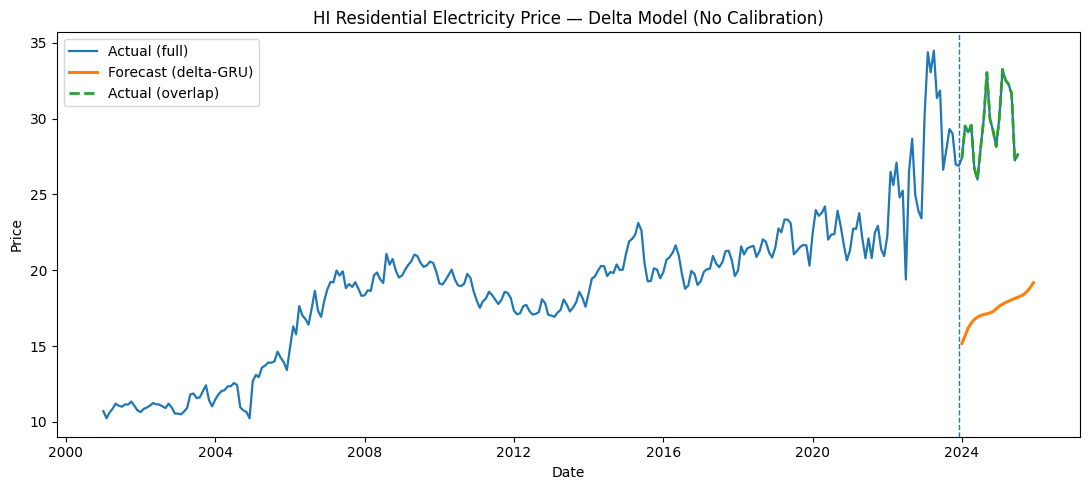

{'MAE_overlap_2024-01_to_2025-07': 12.38804253562786, 'RMSE_overlap_2024-01_to_2025-07': 12.550996181260723}


In [276]:
plt.figure(figsize=(11,5))
plt.plot(df[TARGET].index, df[TARGET].values, label="Actual (full)", linewidth=1.6)

# Forecast from 2024-01; continuous from Dec-2023 by construction
plt.plot(out.index, out["forecast"], label="Forecast (delta-GRU)", linewidth=2.2)

# Dashed actual in the overlap (2024-01..2025-07) if available
overlap = out.dropna(subset=["actual"]).loc["2024-01-01":"2025-07-01"]
if not overlap.empty:
    plt.plot(overlap.index, overlap["actual"], "--", linewidth=2, label="Actual (overlap)")

plt.axvline(SPLIT, linestyle="--", linewidth=1)
plt.title("HI Residential Electricity Price — Delta Model (No Calibration)")
plt.xlabel("Date"); plt.ylabel("Price")
plt.legend(); plt.tight_layout()
plt.show()

# Overlap metrics
if not overlap.empty:
    e = out["forecast"].reindex(overlap.index) - overlap["actual"]
    mae  = float(np.mean(np.abs(e)))
    rmse = float(np.sqrt(np.mean(e**2)))
    print({"MAE_overlap_2024-01_to_2025-07": mae, "RMSE_overlap_2024-01_to_2025-07": rmse})
